# Introduction to Python — Guided Walkthrough
**Mastercard Advisors & Consulting Services · Performance Analytics**  
Facilitators: Furkan Kasapoğlu · Yağız Efe Korkmaz

### 0 · Veri dosyalarını indir
Önce bu hücreyi çalıştırın: veri dosyaları GitHub'dan bu oturuma iner.

In [ ]:
import os, urllib.request
BASE = "https://raw.githubusercontent.com/ardaergene35/python-intro/main/course/"
for f in ["transactions_raw.csv"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(BASE + f, f)
    print('Hazır:', f)

## A · Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## B · Setup & display tricks

In [5]:
# 💡 Show up to 50 columns and don't truncate wide strings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

sns.set_theme(style="whitegrid")
print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 2.3.2 | numpy: 1.26.4


## C · Load the file — but *look* before you commit

**Do not** just `pd.read_csv(...)` and start analyzing. First, peek at the raw text and understand what you have.

In [7]:
preview = pd.read_csv("transactions_raw.csv", nrows=5)
preview

,Card_ID,txn_date,MCC,country,amount,Channel,STATUS
0,C1113,06/06/2024,4111,FR,90.41,NaN,declined
1,C1199,19/07/2024,5812,US,$121.29,ATM,DECLINED
2,C1199,17/05/2024,5541,DE,155.87,MOTO,PENDING
3,C1086,2025-01-23,5812,TR,63.76,,approved
4,C1013,2024-03-23,5999,GB,$166.68,ECOM,Approved


In [9]:
df = pd.read_csv(
    "transactions_raw.csv",
            # 💡
    na_values=["", " ", "NA", "N/A"],     # 💡 treat blanks & single-space as NaN on load
)
print(df.shape)
df.head(3)

(5050, 7)


,Card_ID,txn_date,MCC,country,amount,Channel,STATUS
0,C1113,06/06/2024,4111,FR,90.41,NaN,declined
1,C1199,19/07/2024,5812,US,$121.29,ATM,DECLINED
2,C1199,17/05/2024,5541,DE,155.87,MOTO,PENDING


`skipinitialspace=True` strips whitespace *after* the delimiter.** Saves you from cleaning half your string columns later.

In [11]:
df = pd.read_csv(
    "transactions_raw.csv",
    skipinitialspace=True,                # 💡
    na_values=["", " ", "NA", "N/A"],     # 💡 treat blanks & single-space as NaN on load
)
print(df.shape)
df.head(3)

(5050, 7)


,Card_ID,txn_date,MCC,country,amount,Channel,STATUS
0,C1113,06/06/2024,4111,FR,90.41,NaN,declined
1,C1199,19/07/2024,5812,US,$121.29,ATM,DECLINED
2,C1199,17/05/2024,5541,DE,155.87,MOTO,PENDING


## D · Look before you leap: shape, dtypes, memory, sample

`.sample(5)` beats `.head(5)`.**  
Real files are sorted by date or ID; the first 5 rows lie to you. A random sample tells the truth.

In [12]:
df.sample(5, random_state=1)

,Card_ID,txn_date,MCC,country,amount,Channel,STATUS
3960,C1136,2024-10-25,5812,AZ,$179.48,NaN,Approved
4384,C1003,2024-05-17,5541,GB,203.62,ATM,APPROVED
1796,C1160,20/06/2024,5541,US,$124.16,NaN,declined
2785,C1141,2024-05-01,5541,US,166.54,ECOM,PENDING
1675,C1113,2024-12-31,5541,IT,$-159.28,POS,Approved


`df.info()` shows dtypes *and* non-null counts in one shot. Use it before `describe()`.**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Card_ID   5002 non-null   object
 1   txn_date  5050 non-null   object
 2   MCC       5050 non-null   int64 
 3   country   5050 non-null   object
 4   amount    5050 non-null   object
 5   Channel   2880 non-null   object
 6   STATUS    5050 non-null   object
dtypes: int64(1), object(6)
memory usage: 276.3+ KB


Everything is `object` (string). That is a red flag — `amount`, `MCC`, and dates should be typed.

`memory_usage(deep=True)` shows the *real* memory footprint of object columns.** `memory_usage()` alone lies for strings.

In [15]:
df.memory_usage(deep=True) / 1024   # KB

Index        0.13
Card_ID    265.28
txn_date   290.97
MCC         39.45
country    252.19
amount     271.55
Channel    215.49
STATUS     281.09
dtype: float64

## E · Fix the column names first

Columns like `" amount "` will make **every** `df["amount"]` raise `KeyError`. Fix names before anything else.
`df.columns.str.strip().str.lower()` in one line.

In [16]:
print("Before:", df.columns.tolist())

df.columns = (
    df.columns
      .str.strip()          # remove leading/trailing whitespace
      .str.lower()          # normalize case
)

print("After :", df.columns.tolist())

Before: ['Card_ID ', 'txn_date', 'MCC', 'country ', 'amount ', 'Channel', 'STATUS ']
After : ['card_id', 'txn_date', 'mcc', 'country', 'amount', 'channel', 'status']


## F · Fix dtypes

Try `df["amount"].astype(float)`

In [17]:
df["amount"].astype(float)

ValueError: could not convert string to float: '$121.29'

`df["amount"].astype(float)` will crash.

Try `pd.to_numeric(df["amount"])`

In [19]:
pd.to_numeric(df["amount"])

ValueError: Unable to parse string "$121.29" at position 1

`pd.to_numeric` without `errors="coerce"` will crash. 

The `amount` column (mixed `"$1,250.00"` strings and floats)

Clean the string form *first*, then convert with `errors="coerce"` so bad values become NaN

In [21]:
# Everything is object, so .str is safe
df["amount"] = (
    df["amount"].astype(str)              # force string so .str works uniformly
                 .str.replace("$", "", regex=False)
                 .str.replace(",", "", regex=False)
                 .str.strip()
)
df["amount"] = pd.to_numeric(df["amount"], errors="coerce") 

print("dtype:", df["amount"].dtype)
print("NaN created by conversion:", df["amount"].isna().sum())
df["amount"].describe()

dtype: float64
NaN created by conversion: 0


count      5,050.00
mean       2,360.79
std       21,587.07
min     -232,572.20
25%           76.85
50%          120.23
75%          162.94
max      248,616.92
Name: amount, dtype: float64

### The `txn_date` column (two formats mixed)

`pd.to_datetime(..., format="mixed")` handles multiple formats in the same column (pandas 2.0+ required)

In [22]:
df["txn_date"] = pd.to_datetime(df["txn_date"], format="mixed", dayfirst=True, errors="coerce")
print("dtype:", df["txn_date"].dtype)
print("Failed parses:", df["txn_date"].isna().sum())
print("Range:", df["txn_date"].min(), "→", df["txn_date"].max())

dtype: datetime64[ns]
Failed parses: 0
Range: 2024-01-01 00:00:00 → 2025-06-23 00:00:00


## G · Missing values — three traps

empty strings pretending to be values

⚠️ `""` and `" "` are **not** NaN unless you told `read_csv` so. We already handled it via `na_values=["", " "]`. Verify:

In [28]:
df["channel"].value_counts()   # default HIDES nulls

channel
ECOM    739
ATM     728
MOTO    720
POS     693
Name: count, dtype: int64

### `value_counts()` hides nulls by default

always pass `dropna=False` when profiling categoricals.** This is the single most common source of wrong client numbers.

In [29]:
df["channel"].value_counts(dropna=False)   # now NaN shows up

channel
NaN     2170
ECOM     739
ATM      728
MOTO     720
POS      693
Name: count, dtype: int64

### `== np.nan` is always False

Do **not** write `df[df["channel"] == np.nan]`. It returns zero rows, silently.  
always use `.isna()` / `.notna()`.

In [30]:
wrong = (df["channel"] == np.nan).sum()
right = df["channel"].isna().sum()
print(f"Wrong way: {wrong}  |  Right way: {right}")

Wrong way: 0  |  Right way: 2170


`df.isna().mean().sort_values(ascending=False)` gives % missing per column, ranked.

In [31]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

channel    42.97
card_id     0.95
txn_date    0.00
mcc         0.00
country     0.00
amount      0.00
status      0.00
dtype: float64

Now impute `channel`. Use a semantic default, not `"missing"` alone

In [32]:
df["channel"] = df["channel"].fillna("UNKNOWN")
df["channel"].value_counts(dropna=False)

channel
UNKNOWN    2170
ECOM        739
ATM         728
MOTO        720
POS         693
Name: count, dtype: int64

## H · Duplicates

`keep=False` on `duplicated()` marks *all* copies, not just the extras.

In [33]:
print("Full-row duplicates:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)

Full-row duplicates: 50


,card_id,txn_date,mcc,country,amount,channel,status
242,C1013,2024-06-16,6011,US,166.97,ECOM,APPROVED
807,C1013,2024-06-16,6011,US,166.97,ECOM,APPROVED
3881,C1016,2024-04-30,5999,FR,87.07,ECOM,APPROVED
4676,C1016,2024-04-30,5999,FR,87.07,ECOM,APPROVED
914,C1019,2025-01-20,5812,DE,138.87,UNKNOWN,declined
2062,C1019,2025-01-20,5812,DE,138.87,UNKNOWN,declined


dedupe on a business key, not the whole row.**  
Two rows can look "different" only because of a whitespace difference in one column.

In [35]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Before: {before} Removed {before - len(df)} duplicate rows. Now: {len(df)}")

Removed 50 duplicate rows. Now: 5000


## I · Categorical cleanup

`"APPROVED"`, `"approved"`, and `"Approved "` are **three different categories** to pandas. Same for `"TR "` vs `"TR"`.  
`.str.strip().str.upper()` normalizes at once.**

In [ ]:
df["status"].value_counts(dropna=False)

In [36]:
df["status"]  = df["status"].str.strip().str.upper()
df["country"] = df["country"].str.strip().str.upper()

print(df["status"].value_counts(dropna=False))
print()
print(df["country"].value_counts(dropna=False))

status
APPROVED    2451
DECLINED    1682
PENDING      867
Name: count, dtype: int64

country
FR    789
GB    746
US    717
AZ    711
TR    691
IT    686
DE    660
Name: count, dtype: int64


## J · pandas & numpy basics (with vectorization)

`.loc[]` is inclusive on both ends; `.iloc[]` is exclusive on the end.

In [38]:
df.loc[0:2, ["card_id", "amount"]]     # rows 0, 1, 2  (3 rows!)

,card_id,amount
0,C1113,90.41
1,C1199,121.29
2,C1199,155.87


In [39]:
df.iloc[0:2, 0:2]                       # rows 0, 1        (2 rows)

,card_id,txn_date
0,C1113,2024-06-06
1,C1199,2024-07-19


**vectorized ops are 10–100× faster than `.apply()` or Python loops.**

In [40]:
%timeit df["amount"] * 1.18

125 μs ± 30.6 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [41]:
%timeit df["amount"].apply(lambda x: x * 1.18)

2.42 ms ± 34.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


**`df.query()` reads like English and avoids `df[df[...] & df[...]]` chains.**

In [42]:
df.query("country == 'TR' and amount > 500").shape

(9, 7)

## K · Exploratory Data Analysis

**`describe(percentiles=[...])` shows the tails, where the outliers hide.**

In [44]:
df["amount"].describe()

count      5,000.00
mean       2,361.71
std       21,447.16
min     -232,572.20
25%           76.84
50%          120.21
75%          163.06
max      248,616.92
Name: amount, dtype: float64

In [43]:
df["amount"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99, 0.999])

count      5,000.00
mean       2,361.71
std       21,447.16
min     -232,572.20
1%          -159.63
5%            -6.89
50%          120.21
95%          228.49
99%      131,237.53
99.9%    238,816.73
max      248,616.92
Name: amount, dtype: float64

**`describe(include="all")` profiles numeric AND categorical columns together.**

In [45]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
card_id,4952,200,C1059,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
txn_date,5000,NaN,NaN,NaN,2024-09-25 13:47:42.720000,2024-01-01 00:00:00,2024-05-11 00:00:00,2024-09-27 00:00:00,2025-02-08 00:00:00,2025-06-23 00:00:00,NaN
mcc,"5,000.00",NaN,NaN,NaN,"5,538.56","4,111.00","5,411.00","5,732.00","5,999.00","6,011.00",586.59
country,5000,7,FR,789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,"5,000.00",NaN,NaN,NaN,"2,361.71","-232,572.20",76.84,120.21,163.06,"248,616.92","21,447.16"
channel,5000,5,UNKNOWN,2152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,5000,3,APPROVED,2451,NaN,NaN,NaN,NaN,NaN,NaN,NaN


💡 **Trick 23 — `value_counts(normalize=True)` gives shares directly.** No need to divide manually.

In [48]:
df["country"].value_counts(normalize=True).mul(100).round(2)

country
FR   15.78
GB   14.92
US   14.34
AZ   14.22
TR   13.82
IT   13.72
DE   13.20
Name: proportion, dtype: float64

**`pd.crosstab(...)` is a two-line pivot for two categoricals.**

In [49]:
pd.crosstab(df["country"], df["status"], normalize="index").mul(100).round(1)

status,APPROVED,DECLINED,PENDING
country,,,
AZ,51.30,31.60,17.00
DE,47.10,33.20,19.70
FR,53.70,31.70,14.60
GB,51.10,32.00,16.90
IT,46.50,37.00,16.50
TR,47.30,33.40,19.20
US,45.20,36.80,18.00


### Correlation

`.corr()` **silently ignores** non-numeric columns. Always check what you fed it.  
**pass `numeric_only=True` explicitly (required in pandas 2.x) and confirm which columns went in.**

In [50]:
num = df.select_dtypes(include=np.number)
print("Numeric columns used:", num.columns.tolist())
num.corr(numeric_only=True)

Numeric columns used: ['mcc', 'amount']


,mcc,amount
mcc,1.00,-0.00
amount,-0.00,1.00


## L · Cleaning & transformations

### Outlier capping

**`.clip(upper=q99)` is a one-line winsorization.**

In [51]:
cap = df["amount"].quantile(0.99)
df["amount_capped"] = df["amount"].clip(lower=0, upper=cap)   # also drop refunds for the KPI view
df[["amount", "amount_capped"]].describe(percentiles=[0.95, 0.99])

,amount,amount_capped
count,"5,000.00","5,000.00"
mean,"2,361.71","1,946.14"
std,"21,447.16","14,818.25"
min,"-232,572.20",0.00
50%,120.21,120.21
95%,228.49,228.49
99%,"131,237.53","131,177.27"
max,"248,616.92","131,237.53"


### Binning

**`pd.qcut` gives equal-frequency bins; `pd.cut` gives equal-width bins.**

In [52]:
df["amount_decile"] = pd.qcut(df["amount_capped"], q=10, labels=False, duplicates="drop")
df.groupby("amount_decile", observed=True)["amount_capped"].agg(["count", "min", "max"])

,count,min,max
amount_decile,,,
0,500,0.00,33.22
1,500,33.25,65.57
2,500,65.71,87.17
3,500,87.18,103.63
4,500,103.67,120.19
5,501,120.23,136.22
6,499,136.28,152.91
7,500,152.92,173.89
8,500,173.95,202.00


### Group-level features with `transform`

**`groupby().transform()` returns a Series aligned to the original index.**

In [57]:
df["country_total"] = df.groupby("country", observed=True)["amount_capped"].transform("sum")
df["share_of_country"] = df["amount_capped"] / df["country_total"]
df[["country", "amount_capped", "country_total", "share_of_country"]].head()

,country,amount_capped,country_total,share_of_country
0,FR,90.41,"1,979,667.20",0.00
1,US,121.29,"1,331,200.35",0.00
2,DE,155.87,"948,640.45",0.00
3,TR,63.76,"1,053,921.80",0.00
4,GB,166.68,"1,058,140.65",0.00


### groupby + named aggregation
**named aggregation gives you clean column names in one shot.**

In [58]:
summary = (
    df.groupby("country", observed=True)
      .agg(
          txn_count=("amount", "size"),
          avg_ticket=("amount_capped", "mean"),
          total_spend=("amount_capped", "sum"),
          approval_rate=("status", lambda s: (s == "APPROVED").mean()),
      )
      .sort_values("total_spend", ascending=False)
)
summary

,txn_count,avg_ticket,total_spend,approval_rate
country,,,,
FR,789,"2,509.08","1,979,667.20",0.54
AZ,711,"2,656.86","1,889,024.30",0.51
IT,686,"2,143.01","1,470,103.59",0.47
US,717,"1,856.63","1,331,200.35",0.45
GB,746,"1,418.42","1,058,140.65",0.51
TR,691,"1,525.21","1,053,921.80",0.47
DE,660,"1,437.33","948,640.45",0.47


**`groupby` DROPS NaN keys by default.** If your grouping column has nulls, you lose those rows silently. Use `dropna=False`.

In [61]:
df.groupby("card_id", dropna=False)["amount"].size().tail(3)   # NaN card_ids now appear

card_id
C1198    26
C1199    33
NaN      48
Name: amount, dtype: int64

### Merging with a debug flag
**`merge(..., indicator=True)` adds a `_merge` column telling you `left_only / right_only / both`.** Best debugging tool for joins.

In [62]:
mcc_lookup = pd.DataFrame({
    "mcc":       [5411, 5812, 5541, 5732, 4111, 5999],
    "mcc_group": ["Grocery", "Restaurants", "Fuel", "Electronics", "Transport", "Other Retail"],
})

df = df.merge(mcc_lookup, on="mcc", how="left", indicator=True)
df["_merge"].value_counts()

_merge
both          4294
left_only      706
right_only       0
Name: count, dtype: int64

In [63]:
df.head()

,card_id,txn_date,mcc,country,amount,channel,status,amount_capped,amount_decile,country_total,share_of_country,mcc_group,_merge
0,C1113,2024-06-06,4111,FR,90.41,UNKNOWN,DECLINED,90.41,3,"1,979,667.20",0.00,Transport,both
1,C1199,2024-07-19,5812,US,121.29,ATM,DECLINED,121.29,5,"1,331,200.35",0.00,Restaurants,both
2,C1199,2024-05-17,5541,DE,155.87,MOTO,PENDING,155.87,7,"948,640.45",0.00,Fuel,both
3,C1086,2025-01-23,5812,TR,63.76,UNKNOWN,APPROVED,63.76,1,"1,053,921.80",0.00,Restaurants,both
4,C1013,2024-03-23,5999,GB,166.68,ECOM,APPROVED,166.68,7,"1,058,140.65",0.00,Other Retail,both


In [64]:
# Which MCCs failed to match? (Trick 31 payoff)
df.loc[df["_merge"] == "left_only", "mcc"].value_counts(dropna=False)

mcc
6011    706
Name: count, dtype: int64

In [65]:
df = df.drop(columns="_merge")

### Avoiding SettingWithCopyWarning

Modifying a filtered DataFrame without `.copy()` triggers `SettingWithCopyWarning`. It's not a bug — it's a warning that pandas can't guarantee your change will stick.  
**always `.copy()` after a filter you intend to modify.**

In [66]:
tr = df[df["country"] == "TR"].copy()      # .copy()
tr["is_high_value"] = (tr["amount_capped"] > tr["amount_capped"].quantile(0.9)).astype(int)
tr[["country", "amount_capped", "is_high_value"]].head()

,country,amount_capped,is_high_value
3,TR,63.76,0
13,TR,211.68,1
33,TR,28.51,0
35,TR,133.99,0
36,TR,0.00,0


## M · Simple visualizations

**set `figsize` on every chart. Default matplotlib size is too small for slides.**  
**always call `plt.tight_layout()` to prevent label cutoff when you export to PNG.**

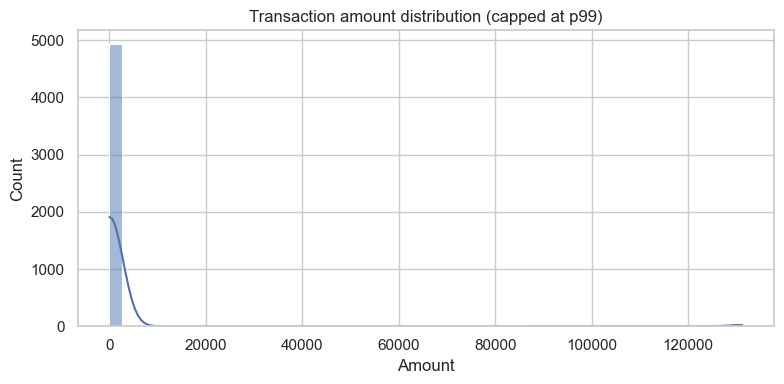

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["amount_capped"], bins=50, kde=True, ax=ax)
ax.set_title("Transaction amount distribution (capped at p99)")
ax.set_xlabel("Amount")
plt.tight_layout()
plt.show()

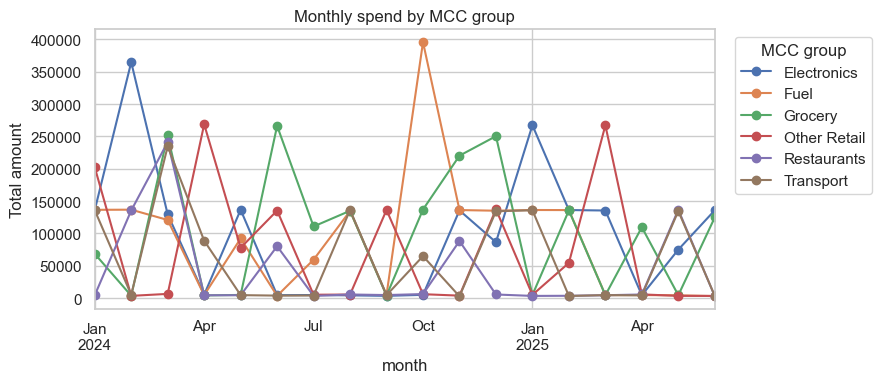

In [68]:
monthly = (
    df.assign(month=df["txn_date"].dt.to_period("M").dt.to_timestamp())
      .groupby(["month", "mcc_group"], observed=True)["amount_capped"].sum()
      .unstack()
)

fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o")
ax.set_title("Monthly spend by MCC group")
ax.set_ylabel("Total amount")
ax.legend(title="MCC group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

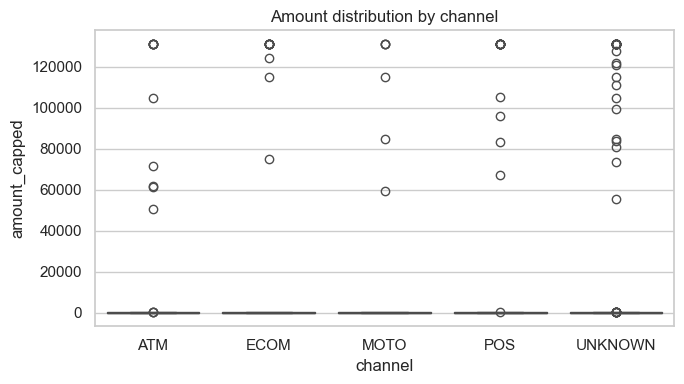

In [69]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="channel", y="amount_capped", ax=ax)
ax.set_title("Amount distribution by channel")
plt.tight_layout()
plt.show()

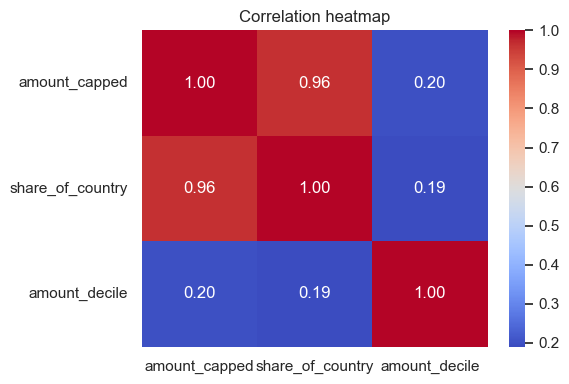

In [70]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    df[["amount_capped", "share_of_country", "amount_decile"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", ax=ax
)
ax.set_title("Correlation heatmap")
plt.tight_layout()
plt.show()

## N · Cheatsheet — the 34 tricks in one place

| # | Trick |
|---|---|
| 1 | `pd.set_option("display.max_columns", 50)` + `display.float_format` |
| 2 | `pd.read_csv(nrows=5)` for fast preview |
| 3 | `skipinitialspace=True` in `read_csv` |
| 4 | `.sample()` beats `.head()` on sorted data |
| 5 | `df.info()` before `describe()` |
| 6 | `memory_usage(deep=True)` for real size |
| 7 | `df.columns.str.strip().str.lower()` |
| 8 | Clean strings *then* `pd.to_numeric(..., errors="coerce")` |
| 9 | `pd.to_datetime(..., format="mixed")` |
| 10 | Nullable `"Int64"` dtype survives NaN |
| 11 | `value_counts(dropna=False)` — always |
| 12 | `== np.nan` is always False — use `.isna()` |
| 13 | `df.isna().mean()` for a one-line health check |
| 14 | `duplicated(keep=False)` marks all copies |
| 15 | Dedupe on business key, not full row |
| 16 | `.str.strip().str.upper()` normalizes categories |
| 17 | `astype("category")` saves memory |
| 18 | `.loc[]` inclusive; `.iloc[]` exclusive |
| 19 | Vectorize; avoid `.apply()` when possible |
| 20 | `df.query("...")` reads like English |
| 21 | `describe(percentiles=[...])` for tails |
| 22 | `describe(include="all")` for mixed dtypes |
| 23 | `value_counts(normalize=True)` for shares |
| 24 | `pd.crosstab` = fast two-way pivot |
| 25 | `.corr(numeric_only=True)` — be explicit |
| 26 | `.clip()` for winsorization |
| 27 | `pd.qcut` for equal-frequency bins |
| 28 | `groupby().transform()` for group-relative features |
| 29 | Named aggregation in `.agg(...)` |
| 30 | `groupby(dropna=False)` — nulls drop silently |
| 31 | `merge(indicator=True)` for join debugging |
| 32 | `.copy()` after filter to avoid `SettingWithCopyWarning` |
| 33 | Always set `figsize` |
| 34 | Always call `plt.tight_layout()` |